In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import recall_score, accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.combine import SMOTEENN
from sklearn.feature_selection import SelectKBest
from collections import Counter

# ignore warning
import warnings
warnings.filterwarnings('ignore')

In [2]:

df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:

l1 = df.loc[df['Churn']== 'Yes'].count()[0]
print(f"Pecentage of Left: {l1/len(df['Churn'])}")
print(df.Churn.value_counts())

Pecentage of Left: 0.2653698707936959
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [4]:
df["TotalCharges"].dtype



dtype('O')

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.isnull().sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
df.TotalCharges = df.TotalCharges.fillna(df.TotalCharges.median())

In [7]:
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True)


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

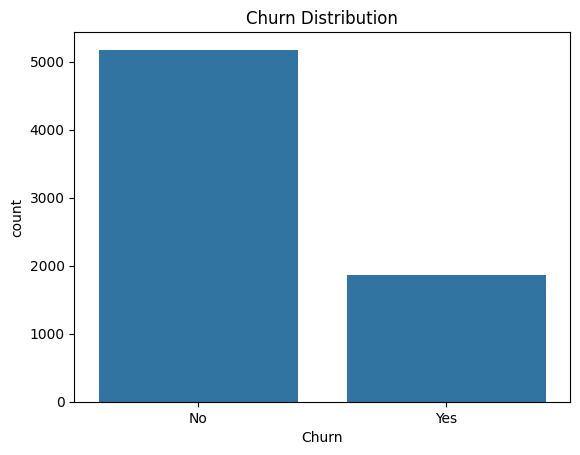

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()


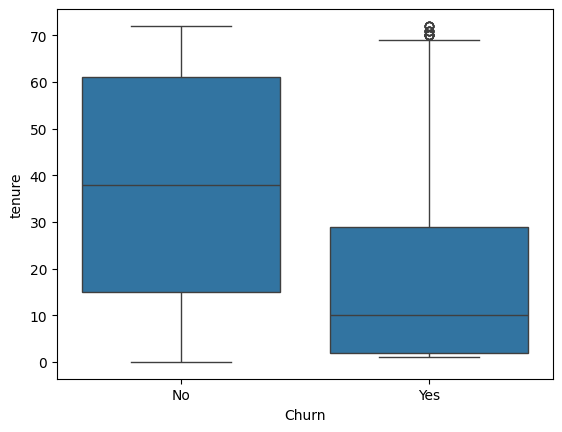

In [9]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()


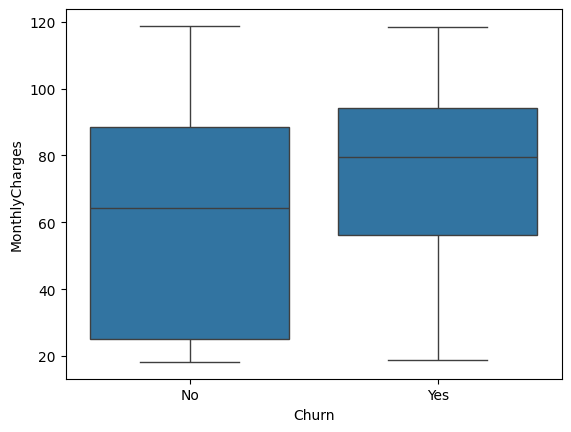

In [10]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()


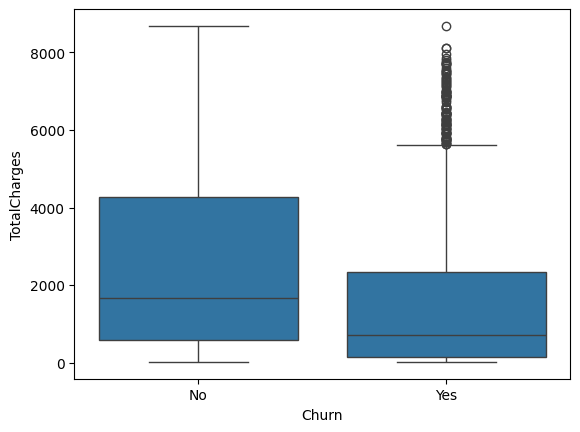

In [11]:
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.show()


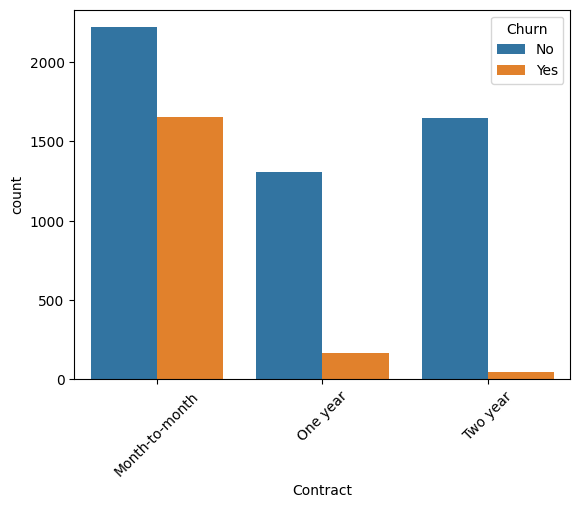

In [12]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.show()


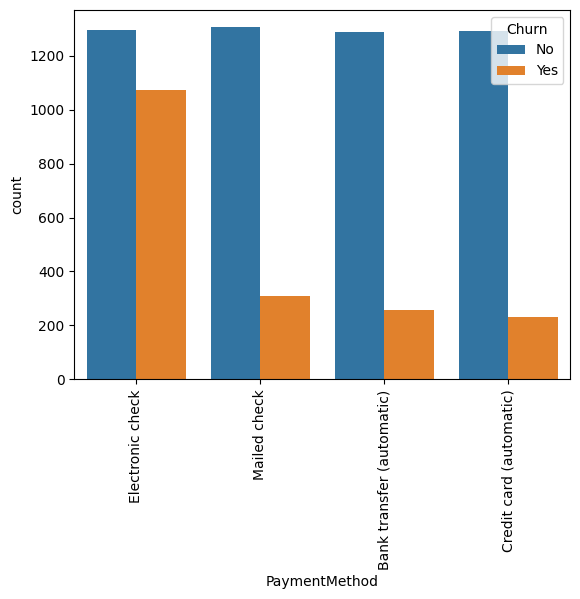

In [13]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=90)
plt.show()


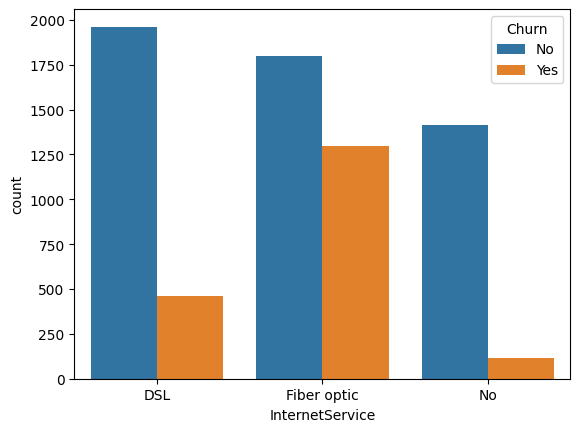

In [14]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()


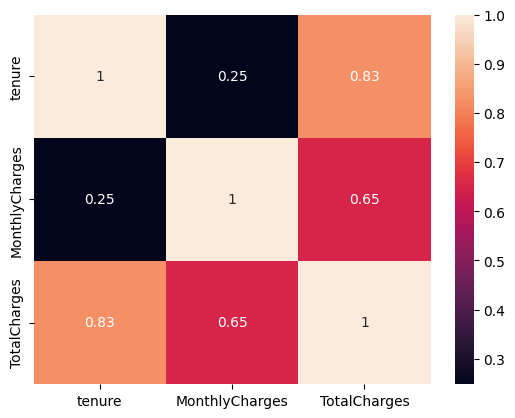

In [15]:
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(), annot=True)
plt.show()


In [16]:

contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index")
contract_churn


Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [17]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=["0-1yr","1-2yr","2-4yr","4-6yr"]
)

pd.crosstab(df["tenure_group"], df["Churn"], normalize="index")


Churn,No,Yes
tenure_group,,
0-1yr,0.523218,0.476782
1-2yr,0.712891,0.287109
2-4yr,0.796110,0.203890
4-6yr,0.904868,0.095132


In [18]:
df["MonthlyCharges_group"] = pd.cut(
    df["MonthlyCharges"],
    bins=5
)

pd.crosstab(df["MonthlyCharges_group"], df["Churn"], normalize="index")


Churn,No,Yes
MonthlyCharges_group,,
"(18.15, 38.35]",0.885921,0.114079
"(38.35, 58.45]",0.730348,0.269652
"(58.45, 78.55]",0.705194,0.294806
"(78.55, 98.65]",0.630340,0.369660
"(98.65, 118.75]",0.699427,0.300573


In [19]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index")


Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


In [20]:
pd.crosstab(df["TechSupport"], df["Churn"], normalize="index")
pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index")


Churn,No,Yes
OnlineSecurity,,
No,0.582333,0.417667
No internet service,0.925950,0.074050
Yes,0.853888,0.146112


In [21]:
pd.crosstab(df["gender"], df["Churn"], normalize="index")


Churn,No,Yes
gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


In [22]:
high_risk = df[(df["Contract"] == "Month-to-month") & (df["tenure"] < 12)]

high_risk["Churn"].value_counts(normalize=True)


Churn
Yes    0.519392
No     0.480608
Name: proportion, dtype: float64

In [23]:
high_price_no_security = df[
    (df["MonthlyCharges"] > df["MonthlyCharges"].median()) &
    (df["OnlineSecurity"] == "No")
]

high_price_no_security["Churn"].value_counts(normalize=True)


Churn
No     0.542718
Yes    0.457282
Name: proportion, dtype: float64

In [24]:
high_risk = df[(df["Contract"] == "Month-to-month") & (df["tenure"] < 12)]

print("Segment size:", len(high_risk))
print(high_risk["Churn"].value_counts(normalize=True))


Segment size: 1908
Churn
Yes    0.519392
No     0.480608
Name: proportion, dtype: float64


In [25]:
df["HighRiskFlag"] = (
    (df["Contract"] == "Month-to-month") &
    (df["tenure"] < 12)
).astype(int)


In [26]:
pd.crosstab(df["HighRiskFlag"], df["Churn"], normalize="index")


Churn,No,Yes
HighRiskFlag,,
0,0.829017,0.170983
1,0.480608,0.519392


In [27]:
df["Churn"] = df["Churn"].map({"No":0, "Yes":1})


In [28]:
df[["HighRiskFlag", "Churn"]].corr()


,HighRiskFlag,Churn
HighRiskFlag,1.000000,0.350696
Churn,0.350696,1.000000


In [29]:
import pandas as pd
import numpy as np

# Copy dataset
df_model = df.copy()

# Drop ID
df_model = df_model.drop("customerID", axis=1)

# Fix TotalCharges
df_model["TotalCharges"] = pd.to_numeric(df_model["TotalCharges"], errors="coerce")

# Fill missing (caused by coercion)
df_model["TotalCharges"] = df_model["TotalCharges"].fillna(df_model["TotalCharges"].median())


In [30]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [32]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns (important!)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]


In [34]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))


Confusion Matrix:
 [[926 109]
 [185 189]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


ROC-AUC Score: 0.8431863390942675


In [35]:
log_model_bal = LogisticRegression(max_iter=1000, class_weight='balanced')


In [36]:
log_model_bal.fit(X_train, y_train)

# Predictions
y_pred_bal = log_model_bal.predict(X_test)
y_prob_bal = log_model_bal.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_bal))

Confusion Matrix:
 [[750 285]
 [ 79 295]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


ROC-AUC Score: 0.8433878426205791


Before vs After (Important)
🔹 Original Logistic

Recall (churn) = 0.51

Accuracy = 0.79

ROC-AUC = 0.84

🔹 Balanced Logistic

Recall (churn) = 0.79 ⬆️🔥

Accuracy = 0.74 ⬇️

ROC-AUC = 0.84 (almost same)

In [37]:
y_prob = log_model_bal.predict_proba(X_test)[:,1]
y_pred_custom = (y_prob > 0.35).astype(int)


In [38]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

# Now get probabilities
y_prob = log_model.predict_proba(X_test)[:, 1]

In [39]:
for threshold in [0.5, 0.4, 0.3]:
    print(f"\nThreshold: {threshold}")
    
    y_pred_custom = (y_prob >= threshold).astype(int)
    
    print(confusion_matrix(y_test, y_pred_custom))
    print(classification_report(y_test, y_pred_custom))



Threshold: 0.5
[[926 109]
 [185 189]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


Threshold: 0.4
[[859 176]
 [131 243]]
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1035
           1       0.58      0.65      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.79      1409


Threshold: 0.3
[[777 258]
 [ 86 288]]
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro av

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'

)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))


Confusion Matrix:
 [[930 105]
 [198 176]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.63      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409


ROC-AUC Score: 0.8237851662404092


In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="roc_auc"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC (CV):", grid.best_score_)


Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best ROC-AUC (CV): 0.8472911914467358


In [42]:
best_log = grid.best_estimator_

y_pred_best = best_log.predict(X_test)
y_prob_best = best_log.predict_proba(X_test)[:,1]

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))


[[925 110]
 [186 188]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8437960164302876


In [43]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_log.coef_[0]
})

# Sort by absolute importance
coef_df["abs_coef"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

coef_df.head(15)


,Feature,Coefficient,abs_coef
26,Contract_Two year,-1.414965,1.414965
11,InternetService_Fiber optic,1.110998,1.110998
25,Contract_One year,-0.660117,0.660117
33,tenure_group_4-6yr,0.636132,0.636132
17,DeviceProtection_No internet service,-0.618280,0.618280
4,HighRiskFlag,0.435342,0.435342
8,PhoneService_Yes,-0.413270,0.413270
27,PaperlessBilling_Yes,0.377354,0.377354
14,OnlineSecurity_Yes,-0.371070,0.371070
10,MultipleLines_Yes,0.355095,0.355095


In [44]:
# Count how many features were zeroed
(coef_df["Coefficient"] == 0).sum()


np.int64(2)

In [45]:
from sklearn.ensemble import GradientBoostingClassifier


In [46]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_gb))


Confusion Matrix:
 [[938  97]
 [182 192]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


ROC-AUC Score: 0.8430558784778732


In [47]:
import numpy as np

threshold = 0.4
y_pred_gb_thresh = (y_prob_gb >= threshold).astype(int)

print("Confusion Matrix (Threshold=0.4):\n", confusion_matrix(y_test, y_pred_gb_thresh))
print("\nClassification Report (Threshold=0.4):\n", classification_report(y_test, y_pred_gb_thresh))


Confusion Matrix (Threshold=0.4):
 [[868 167]
 [135 239]]

Classification Report (Threshold=0.4):
               precision    recall  f1-score   support

           0       0.87      0.84      0.85      1035
           1       0.59      0.64      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.74      0.73      1409
weighted avg       0.79      0.79      0.79      1409



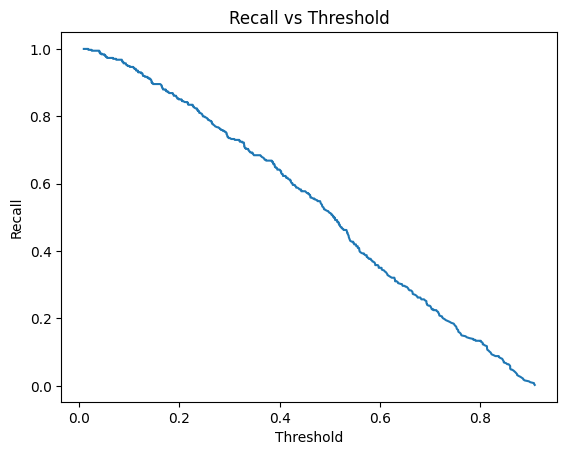

In [48]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_gb)

plt.plot(thresholds, recall[:-1])
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Recall vs Threshold")
plt.show()


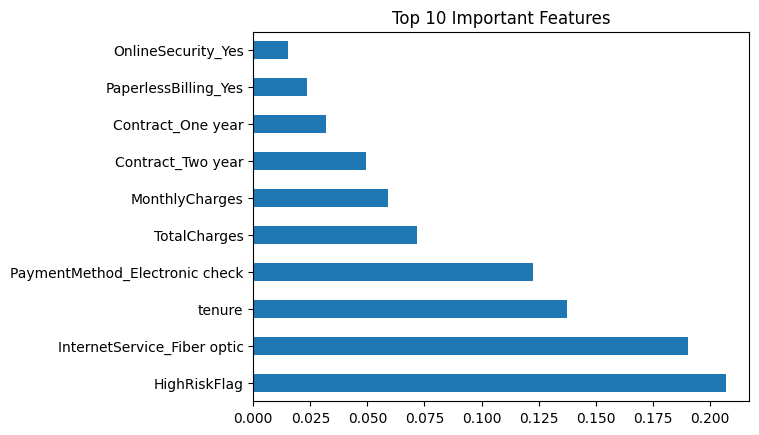

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(gb_model.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()


In [50]:
# Clean column names for XGBoost
X_train.columns = X_train.columns.str.replace('[', '', regex=False)
X_train.columns = X_train.columns.str.replace(']', '', regex=False)
X_train.columns = X_train.columns.str.replace('<', '', regex=False)

X_test.columns = X_test.columns.str.replace('[', '', regex=False)
X_test.columns = X_test.columns.str.replace(']', '', regex=False)
X_test.columns = X_test.columns.str.replace('<', '', regex=False)


In [51]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Calculate imbalance ratio
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
y_pred_xgb = (y_prob_xgb >= 0.45).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


Confusion Matrix:
 [[736 299]
 [ 72 302]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


ROC-AUC: 0.8395295667674184


In [52]:
for t in [0.5, 0.45, 0.4]:
    y_pred_temp = (y_prob_xgb >= t).astype(int)
    print("\nThreshold:", t)
    print(classification_report(y_test, y_pred_temp))



Threshold: 0.5
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409


Threshold: 0.45
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.91      0.67      0.78      1035
           1       0.48      0.83      0.60       374

    accuracy                           0.71      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80  

In [53]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb = XGBClassifier(scale_pos_weight=3, random_state=42)

grid = GridSearchCV(
    xgb,
    param_grid,
    scoring='recall',   # optimize directly for recall
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


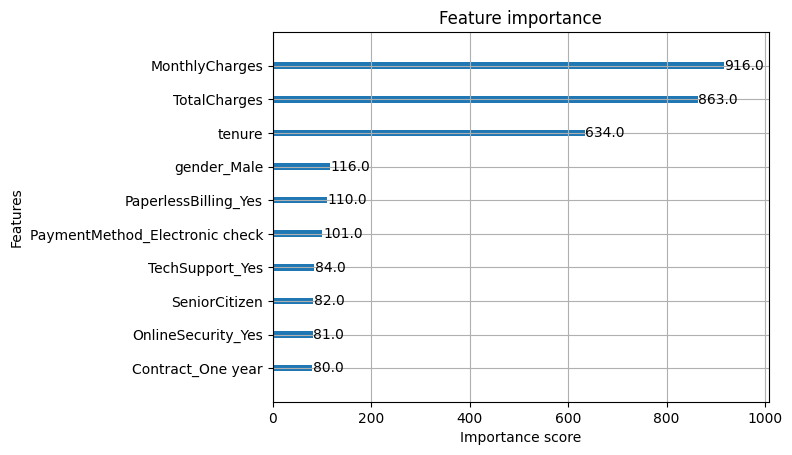

In [54]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(xgb_model, max_num_features=10)
plt.show()


In [55]:
risk_bucket = []

for p in y_prob_xgb:
    if p >= 0.6:
        risk_bucket.append("High Risk")
    elif p >= 0.45:
        risk_bucket.append("Medium Risk")
    else:
        risk_bucket.append("Low Risk")


In [56]:
import joblib
joblib.dump(xgb_model, "churn_model_xgboost.pkl")


['churn_model_xgboost.pkl']

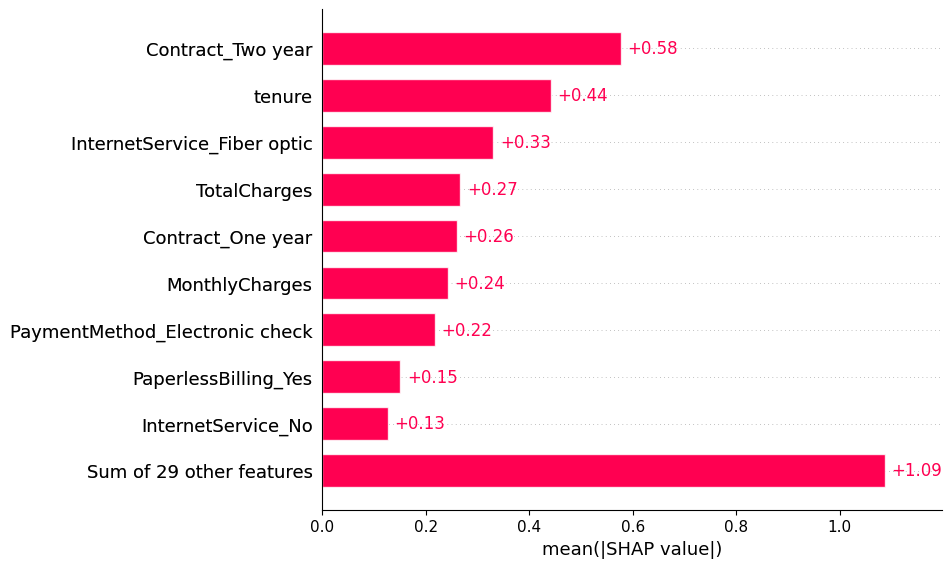

In [57]:
import shap

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)


In [58]:
import os
os.makedirs("model", exist_ok=True)

joblib.dump(xgb_model, "model/churn_model_xgboost.pkl")
joblib.dump(X_train.columns, "model/model_columns.pkl")

['model/model_columns.pkl']